# EDA: Filtered Data

## Load data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

DATA_FILES = {
    "2023-01-04": "/Users/maxwellcheng/Downloads/spx_options_processed_2023-01-04.csv",
    "2023q2": "/Users/maxwellcheng/Downloads/spx_options_processed_2023q2.csv",
}

# Kept separate on purpose: the two files were filtered differently
# (see the comparison section), so pooling them would mix populations.
datasets = {}
for label, path in DATA_FILES.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower()
    df["quote_date"] = pd.to_datetime(df["quote_date"])
    df["expire_date"] = pd.to_datetime(df["expire_date"])
    datasets[label] = df

d1 = datasets["2023-01-04"]
d2 = datasets["2023q2"]

{label: df.shape for label, df in datasets.items()}

{'2023-01-04': (4151, 33), '2023q2': (7897, 34)}

## EDA: 2023-01-04

In [2]:
d1[["dte", "strike_distance_pct", "c_iv", "p_iv"]].describe()

,dte,strike_distance_pct,c_iv,p_iv
count,4151.000000,4151.000000,4114.000000,3626.000000
mean,58.144621,0.069238,0.191308,0.228261
std,50.598582,0.051888,0.056599,0.038478
min,7.000000,0.000000,-0.000260,0.140150
25%,20.000000,0.026000,0.180523,0.203593
50%,33.000000,0.058000,0.201650,0.222230
75%,85.960000,0.105000,0.220485,0.245918
max,176.960000,0.200000,0.570420,0.500990


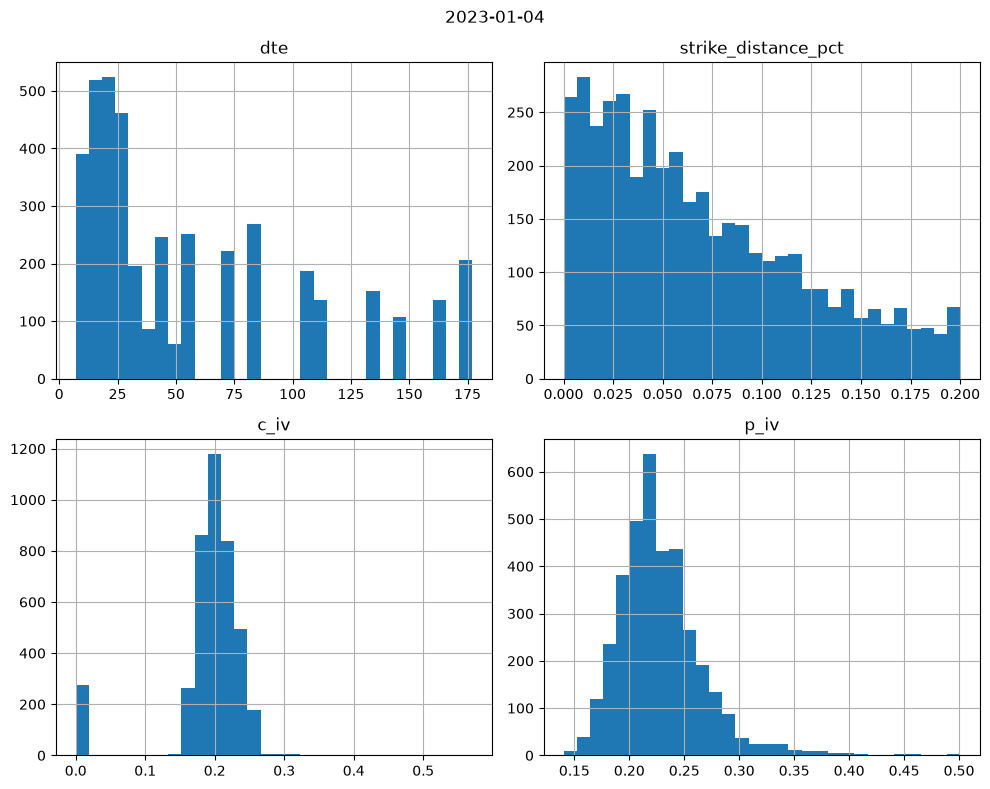

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
d1["dte"].hist(bins=30, ax=axes[0, 0]); axes[0, 0].set_title("dte")
d1["strike_distance_pct"].hist(bins=30, ax=axes[0, 1]); axes[0, 1].set_title("strike_distance_pct")
d1["c_iv"].dropna().hist(bins=30, ax=axes[1, 0]); axes[1, 0].set_title("c_iv")
d1["p_iv"].dropna().hist(bins=30, ax=axes[1, 1]); axes[1, 1].set_title("p_iv")
fig.suptitle("2023-01-04")
fig.tight_layout()

### IV surface

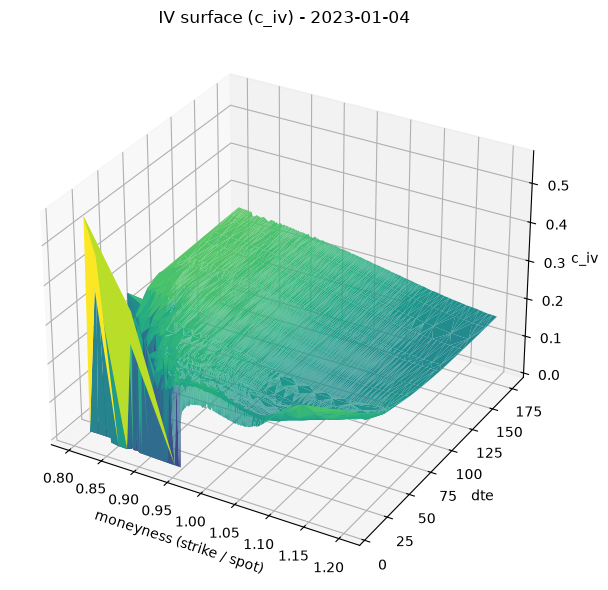

In [4]:
def plot_iv_surface(df, label, iv_col="c_iv", iv_max=3.0):
    surf = df.copy()
    surf["moneyness"] = surf["strike"] / surf["underlying_last"]
    surf = surf.dropna(subset=[iv_col])
    surf = surf[(surf[iv_col] > 0) & (surf[iv_col] < iv_max) & (surf["dte"] > 0)]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection="3d")
    ax.plot_trisurf(surf["moneyness"], surf["dte"], surf[iv_col], cmap="viridis", linewidth=0.1)
    ax.set_xlabel("moneyness (strike / spot)")
    ax.set_ylabel("dte")
    ax.set_zlabel(iv_col)
    ax.set_title(f"IV surface ({iv_col}) - {label}")
    fig.tight_layout()
    return fig, ax

plot_iv_surface(d1, "2023-01-04");

## EDA: 2023q2

In [5]:
d2[["dte", "strike_distance_pct", "c_iv", "p_iv"]].describe()

,dte,strike_distance_pct,c_iv,p_iv
count,7897.000000,7897.000000,7818.000000,6604.000000
mean,128.056837,0.163337,0.459281,0.317077
std,218.551740,0.186794,1.316547,0.453638
min,0.000000,0.000000,-0.000500,0.000150
25%,18.000000,0.038000,0.134655,0.136487
50%,49.000000,0.096000,0.209750,0.204580
75%,153.040000,0.214000,0.341878,0.316047
max,1631.040000,1.696000,51.555620,10.437180


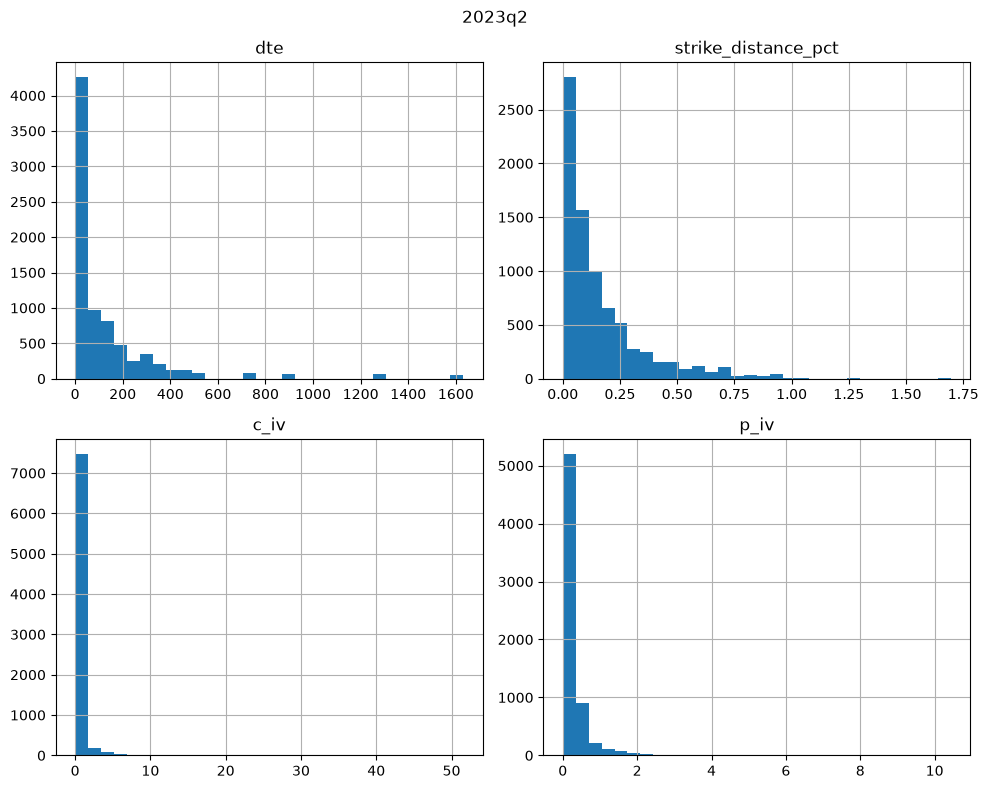

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
d2["dte"].hist(bins=30, ax=axes[0, 0]); axes[0, 0].set_title("dte")
d2["strike_distance_pct"].hist(bins=30, ax=axes[0, 1]); axes[0, 1].set_title("strike_distance_pct")
d2["c_iv"].dropna().hist(bins=30, ax=axes[1, 0]); axes[1, 0].set_title("c_iv")
d2["p_iv"].dropna().hist(bins=30, ax=axes[1, 1]); axes[1, 1].set_title("p_iv")
fig.suptitle("2023q2")
fig.tight_layout()

### IV surface

`2023q2` includes rows that produce nonsensical IVs (up to
5000%+), so this reuses `plot_iv_surface`'s default `iv_max=3.0` clip — for
plotting only, to keep the surface readable.

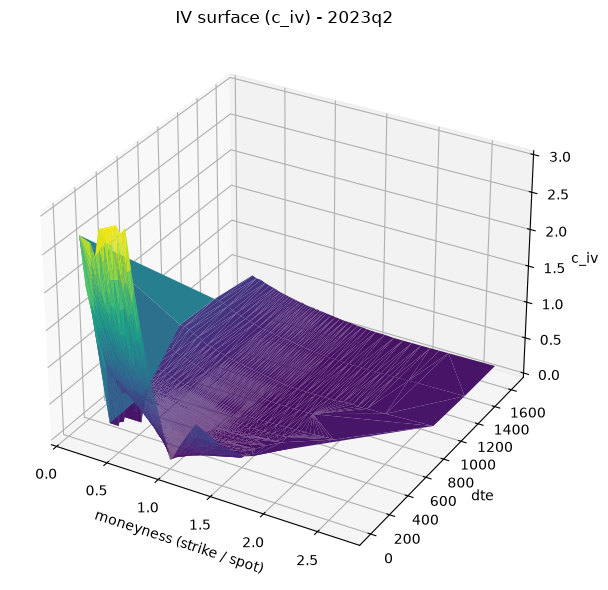

In [7]:
plot_iv_surface(d2, "2023q2");

## Comparing the two EDAs: effect of filtering

The files aren't filtered the same way: `2023-01-04` is
capped at `strike_distance_pct <= 0.20` and `dte >= 7`, while `2023q2` goes out
to `strike_distance_pct` ~1.7. That
difference explains some of what differs below.

In [8]:
summary = pd.DataFrame({
    label: {
        "rows": len(df),
        "dte_min": df["dte"].min(),
        "dte_max": df["dte"].max(),
        "strike_dist_pct_min": df["strike_distance_pct"].min(),
        "strike_dist_pct_max": df["strike_distance_pct"].max(),
        "c_iv_min": df["c_iv"].min(),
        "c_iv_median": df["c_iv"].median(),
        "c_iv_max": df["c_iv"].max(),
    }
    for label, df in datasets.items()
}).T

summary

,rows,dte_min,dte_max,strike_dist_pct_min,strike_dist_pct_max,c_iv_min,c_iv_median,c_iv_max
2023-01-04,4151.0,7.0,176.96,0.0,0.200,-0.00026,0.20165,0.57042
2023q2,7897.0,0.0,1631.04,0.0,1.696,-0.00050,0.20975,51.55562


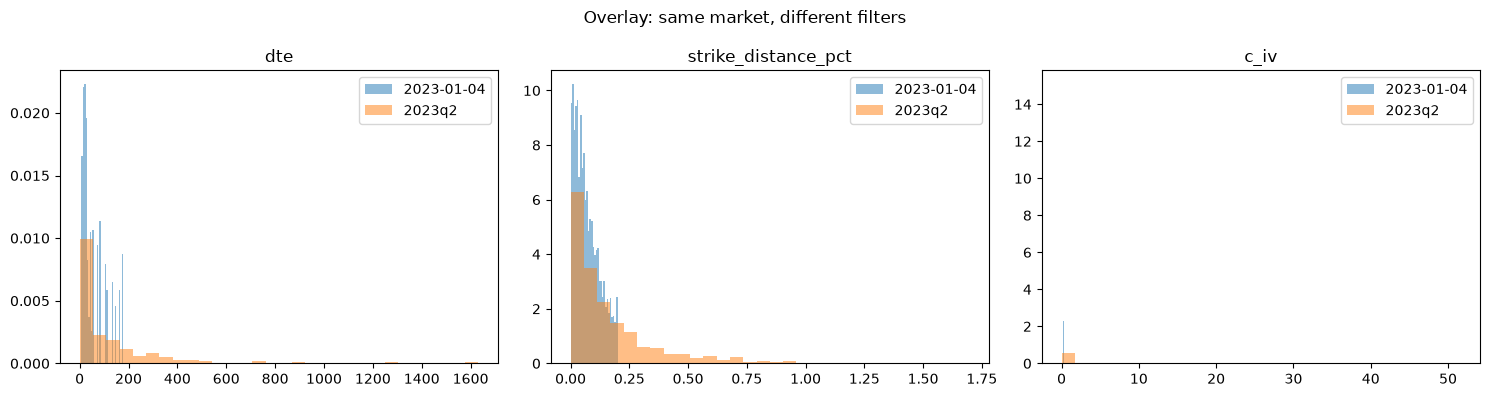

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for label, df in datasets.items():
    axes[0].hist(df["dte"], bins=30, alpha=0.5, label=label, density=True)
    axes[1].hist(df["strike_distance_pct"], bins=30, alpha=0.5, label=label, density=True)
    axes[2].hist(df["c_iv"].dropna(), bins=30, alpha=0.5, label=label, density=True)

axes[0].set_title("dte")
axes[1].set_title("strike_distance_pct")
axes[2].set_title("c_iv")
for ax in axes:
    ax.legend()
fig.suptitle("Overlay: same market, different filters")
fig.tight_layout()

## EDA: 2023 full year

`spx_options_2023_filtered.csv` is a different dataset from the two above —
249 trading days (all of 2023) in **long format** (one row per
`quote_date` x `expiration` x `strike` x `option_type`, with `option_type`
as `call`/`put` rather than `c_*`/`p_*` column pairs). Its filtering
(`dte` 7-365, `strike_distance_pct` 0-0.2, no NaN/garbage IVs) is close to
`2023-01-04`'s, just applied across the whole year. Kept as its own section
rather than merged with `d1`/`d2` since the schema doesn't line up.

In [10]:
FULL_YEAR_PATH = "/Users/maxwellcheng/Downloads/spx_options_2023_filtered.csv"

d3 = pd.read_csv(
    FULL_YEAR_PATH,
    dtype={"option_type": "category"},
    parse_dates=["quote_date", "expire_date"],
)
d3["moneyness"] = d3["strike"] / d3["underlying_last"]

print(d3.shape)
d3[["dte", "strike_distance_pct", "iv"]].describe()

(1765972, 25)


,dte,strike_distance_pct,iv
count,1.765972e+06,1.765972e+06,1.765972e+06
mean,8.930687e+01,5.416032e-02,1.746585e-01
std,8.610683e+01,4.698327e-02,5.260621e-02
min,7.000000e+00,0.000000e+00,4.277000e-02
25%,2.300000e+01,1.800000e-02,1.359400e-01
50%,5.600000e+01,4.000000e-02,1.705200e-01
75%,1.330000e+02,7.800000e-02,2.072100e-01
max,3.650000e+02,2.000000e-01,1.000400e+00


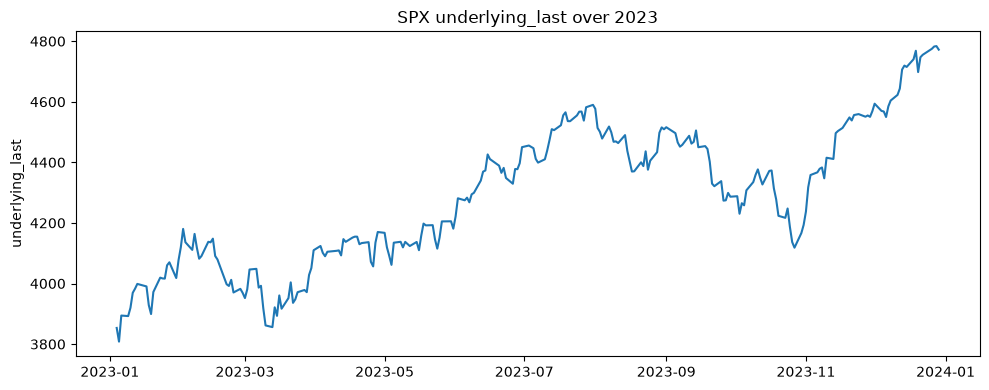

In [11]:
spot_by_date = d3.drop_duplicates("quote_date")[["quote_date", "underlying_last"]].sort_values("quote_date")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(spot_by_date["quote_date"], spot_by_date["underlying_last"])
ax.set_title("SPX underlying_last over 2023")
ax.set_ylabel("underlying_last")
fig.tight_layout()

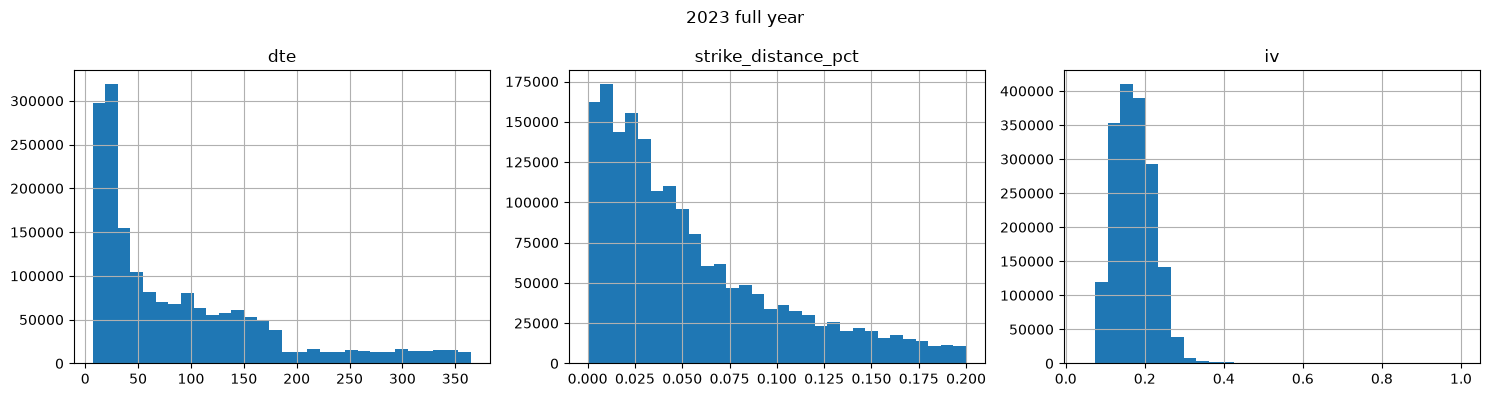

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
d3["dte"].hist(bins=30, ax=axes[0]); axes[0].set_title("dte")
d3["strike_distance_pct"].hist(bins=30, ax=axes[1]); axes[1].set_title("strike_distance_pct")
d3["iv"].hist(bins=30, ax=axes[2]); axes[2].set_title("iv")
fig.suptitle("2023 full year")
fig.tight_layout()

### IV surface (year-average)

Averaging the IV across every day in 2023 and every strike. Note that this will blend the elevated volatility in the first few months of 2023 during which there was a large post 2022 selloff and banking stress (SVB, etc) with calmer months later in the year. 

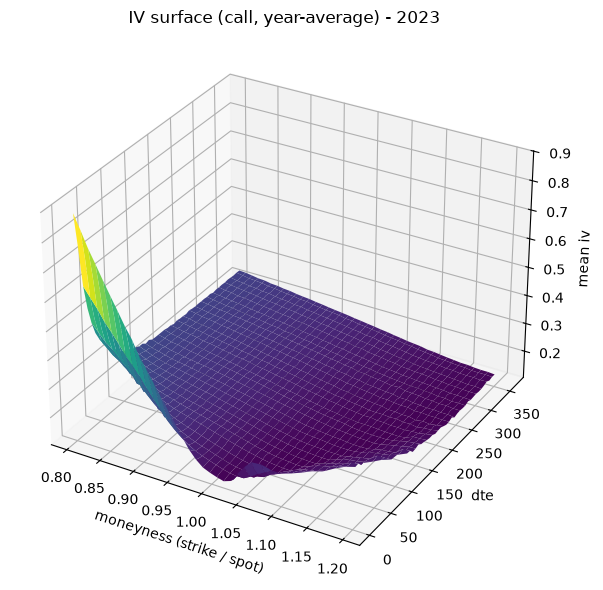

In [13]:
import numpy as np

calls = d3[d3["option_type"] == "call"].copy()

moneyness_bins = np.linspace(0.8, 1.2, 41)
dte_bins = np.arange(0, 371, 7)
calls["moneyness_bin"] = pd.cut(calls["moneyness"], moneyness_bins)
calls["dte_bin"] = pd.cut(calls["dte"], dte_bins)

iv_surface = calls.pivot_table(
    index="dte_bin", columns="moneyness_bin", values="iv", aggfunc="mean", observed=True
)

X, Y = np.meshgrid(
    [interval.mid for interval in iv_surface.columns],
    [interval.mid for interval in iv_surface.index],
)
Z = iv_surface.values

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis")
ax.set_xlabel("moneyness (strike / spot)")
ax.set_ylabel("dte")
ax.set_zlabel("mean iv")
ax.set_title("IV surface (call, year-average) - 2023")
fig.tight_layout()

### Market-moving events in 2023

By (1) looking for the largest 5 up and down days and (2) looking at calls within 2% of spot and 20-40 days to expiration, we can see that the March banking crisis produced a lasting shift in the market's priced in volatility compared to spikes on event days themselves (e.g. the 1/06 jobs report).

In [14]:
spot_returns = spot_by_date.copy()
spot_returns["ret"] = spot_returns["underlying_last"].pct_change()

# Near-the-money, ~1-month IV as a rough daily "market fear" proxy
atm = d3[(d3["option_type"] == "call") & (d3["strike_distance_pct"] < 0.02) & (d3["dte"].between(20, 40))]
atm_iv_by_date = atm.groupby("quote_date")["iv"].mean().rename("atm_iv").reset_index()

daily = spot_returns.merge(atm_iv_by_date, on="quote_date", how="left")

big_moves = pd.concat([daily.nsmallest(5, "ret"), daily.nlargest(5, "ret")]).sort_values("quote_date")
big_moves

,quote_date,underlying_last,ret,atm_iv
2,2023-01-06,3894.20,0.022586,0.193911
11,2023-01-20,3971.98,0.018676,0.174832
32,2023-02-21,3997.57,-0.020064,0.198230
44,2023-03-09,3918.94,-0.018402,0.225774
53,2023-03-22,3936.17,-0.016882,0.210984
76,2023-04-25,4071.66,-0.015694,0.164590
78,2023-04-27,4135.15,0.019386,0.134319
179,2023-09-21,4329.76,-0.016395,0.152424
209,2023-11-02,4317.96,0.018964,0.135777
217,2023-11-14,4496.43,0.019319,0.106065


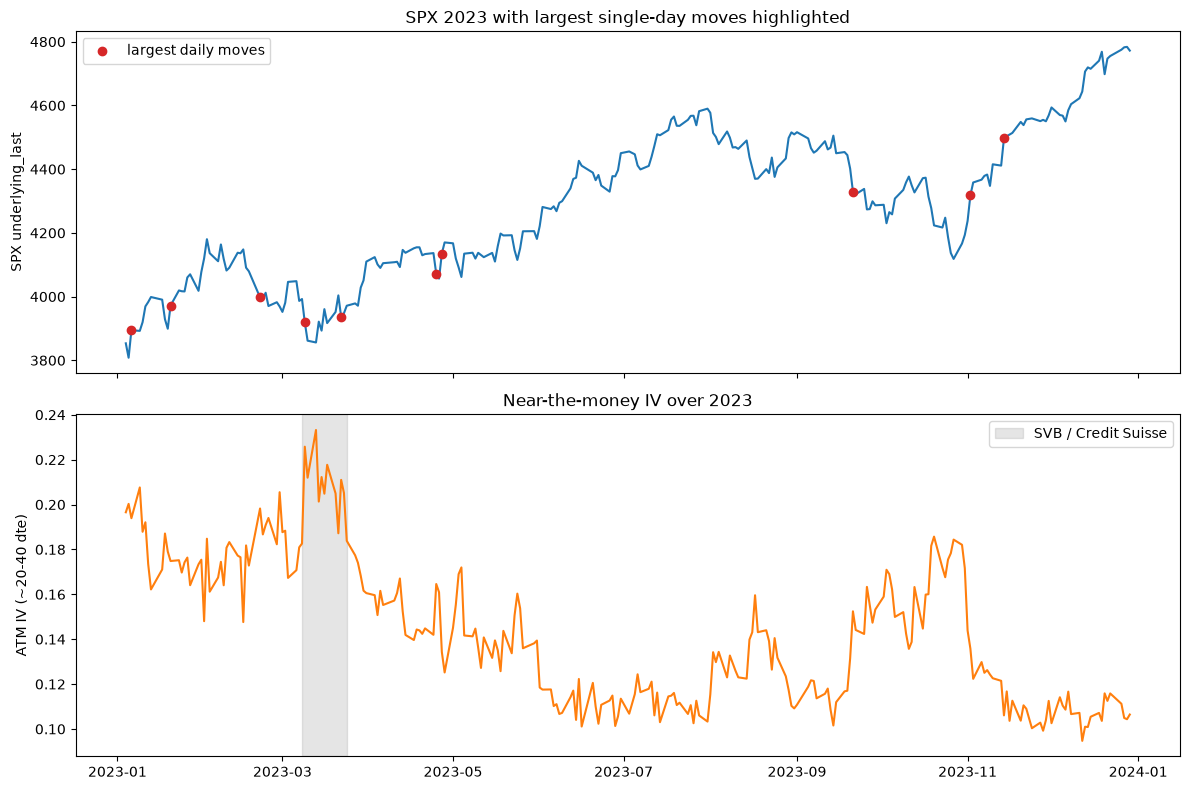

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(daily["quote_date"], daily["underlying_last"], color="tab:blue")
ax1.scatter(big_moves["quote_date"], big_moves["underlying_last"], color="tab:red", zorder=5, label="largest daily moves")
ax1.set_ylabel("SPX underlying_last")
ax1.set_title("SPX 2023 with largest single-day moves highlighted")
ax1.legend()

ax2.plot(daily["quote_date"], daily["atm_iv"], color="tab:orange")
ax2.axvspan(pd.Timestamp("2023-03-08"), pd.Timestamp("2023-03-24"), color="grey", alpha=0.2, label="SVB / Credit Suisse")
ax2.set_ylabel("ATM IV (~20-40 dte)")
ax2.set_title("Near-the-money IV over 2023")
ax2.legend()

fig.tight_layout()

The near ATM IV panel is the more interesting; the shaded March window is
visibly higher than the rest of 2023 and then decays back down into the second half of the year even as price keeps moving. That's IV
pricing in event/contagion risk, not just realized volatility.